# Crystal Identification
## Clustering Analysis & Digital Dark Field Images

In this notebook, the process for crystal identification is covered by applying clustering analysis on the previously obtained COM clusters and by producing Digital Dark Field images to intepret results and to check the efficiency of the input parameters on DBSCAN. 

Sources for data:
- PeaksArray dataset from: [2 - Bragg Peaks and Centering Notebook](https://github.com/2779765h/ACPP/blob/main/Notebooks/2%20-%20Bragg%20Peaks%20and%20Centering.ipynb)
- COM_Values, db1labels, db2labels are from: [3 - DBSCAN Clustering Notebook](https://github.com/2779765h/ACPP/blob/main/Notebooks/3%20-%20DBSCAN%20Clustering.ipynb)


### Import packages and load data

Import DBSCAN and other required libraries

In [1]:
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string

Load data and clustering labels obtained from the DBSCAN Clustering Notebook

In [2]:
PeaksArray = np.load('data/PeaksArray_SmallRange.npy')
COM_Values = np.load('data/COM_Values.npy')
db1labels = np.load('data/db1labels.npy')
db2labels = np.load('data/db2labels.npy')

### Digital Dark Field Function

As in previous notebooks, a VirtualImage function can be defined that selects an individual cluster from the application of DBSCAN clustering and creates a Digital Dark Field (DDF) image, plotting in intensity and in the real space. The DDF image can then be used to examine the cluster size, intesity, shape and its positioning in the real space and compare it back to the sample. It can also be used to identitfy if clusters have been seperated efficiently through the DBSCAN parameters. 

In [3]:
def VirtualImage(Data, Label, Index, savefig = True, figax = None):
    '''
    Function which produces the Digital Dark Field Image of a selected cluster.

    Data types:
    Data: numpy array
    Label: numpy array
        this corresponds to the clustering type, so for DBSCAN use db.labels_
        
    Index: Int
        select the index of the cluster
    figax: tuple, None
        (fig, ax)
    
    Return: 
    '''
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 3]
    Ryc = Cluster[:, 4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Data[:,3].max().astype('int')+1, Data[:,4].max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,2]

    # Plot
    if figax != None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(figsize=[7,7])

    ax.imshow(image)
      
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()
         
    if savefig:
        fig.savefig('DigitalDarkFieldImage')

**Standardise text size for all figures**

In [4]:
plt.rcParams.update({
    'font.size': 12,      
    'axes.titlesize': 16,   
    'axes.labelsize': 14,   
    'xtick.labelsize': 11,  
    'ytick.labelsize': 11,  
    'legend.fontsize': 12
})

### Transfer level 1 and level 2 cluster labels into the full data array 

In order to be able to obtain the diffraction vectors associated with each crystal, it will be useful to add the level 1 and 2 clustering labels back to the original PeaksArray dataset. So, that by filtering on an individual crystal, say 'A', all the level 1 clusters contained withing 'A' are also selected and therefore, so are the real and diffraction space coordinates.  Then one of these crystals can be plotted as a Digital Dark Field image and analysed. 

The unique labels from the level 2 clusters are identified, in order for the numbers to be in ascending order and the noise cluster '-1' is moved to be at the finial position to ensure that it remains as cluster Z during the analysis.

In [7]:
L2Unique = np.unique(db2labels) 
L2numlabs = np.append(L2Unique[L2Unique != -1], -1) # set last number to be -1

Using the string package, alphabetical letters are inserted and set to be the same length as the number of unqiue clusters. 

In [9]:
L2letterlabs = string.ascii_uppercase[:L2numlabs.shape[0]]

A dictionary is formed in order to be able to map between both numbers and letters for the clusters.

In [10]:
labs1 = dict(list(zip(L2numlabs, L2letterlabs))) # numbers to letters
labs2 = dict(list(zip(L2letterlabs, L2numlabs))) # letters to numbers

The noise cluser is the overwritten from the dictionaries to ensure it remains as cluster Z = -1

In [12]:
labs1[-1] = 'Z'
labs2['Z'] = -1

Add level 1 labels to the PeaksArray as a new column

In [13]:
Dataset = np.column_stack((PeaksArray, db1labels))

Apply index to ensure correct length of level 2 labels and to map level 1 clusters to level 2 clusters. This indexing works by selecing the level 1 label, and it output the corresponding level 2 label, which is it being contained in.

In [21]:
indexing = db2labels[db1labels]

Then use the indexing and the dictionary to map the numbers in the array to the corresponding letters and form a letter array. Which will output a letter array for the level 2 labels.

In [24]:
# Source - https://stackoverflow.com/a/57058920
# Posted by yatu
# Retrieved 2026-03-15, License - CC BY-SA 4.0
lvl2 = np.vectorize(labs1.get)(indexing.astype(int))

Add level 1 labels to the Dataset as a new column

In [25]:
# Add level 2 labels to data array
FullDataset = np.column_stack((Dataset, lvl2))

This means that the PeaksArray dataset has now been extended with two new columns corresponding to both level 1 and level 2 clustering labels, written as Clusters1 and Clusters2, respectively.

In [26]:
# New Data Array Columns
Qx = FullDataset[:,0]
Qy = FullDataset[:,1]
I = FullDataset[:,2]
Rx = FullDataset[:,3]
Ry = FullDataset[:,4] 
Qr = FullDataset[:,5]
Qphi = FullDataset[:,6]
Clusters1 = FullDataset[:,7]
Clusters2 = FullDataset[:,8] 

### Digital dark field images of individual crystals 

The data can be filtered by the individual crystal (or letter) label and plotted as a Digital Dark Field images, so that the clusters can be analysed. The cluster should contain diffraction vectors which belong to the individual crystal.

Apply conversion of data into float and integers, calculate maximum values and add one to ensure the full array length is covered.

In [51]:
FullDataSetFloat1 = FullDataset[:, 3].astype('float')
C1 = FullDataSetFloat1.max().astype('int')+1

FullDataSetFloat2 = FullDataset[:, 4].astype('float')
C2 = FullDataSetFloat2.max().astype('int')+1

Then run a loop through each crystal, level 2 cluster label, and plot a DDF images as subplots as shown.

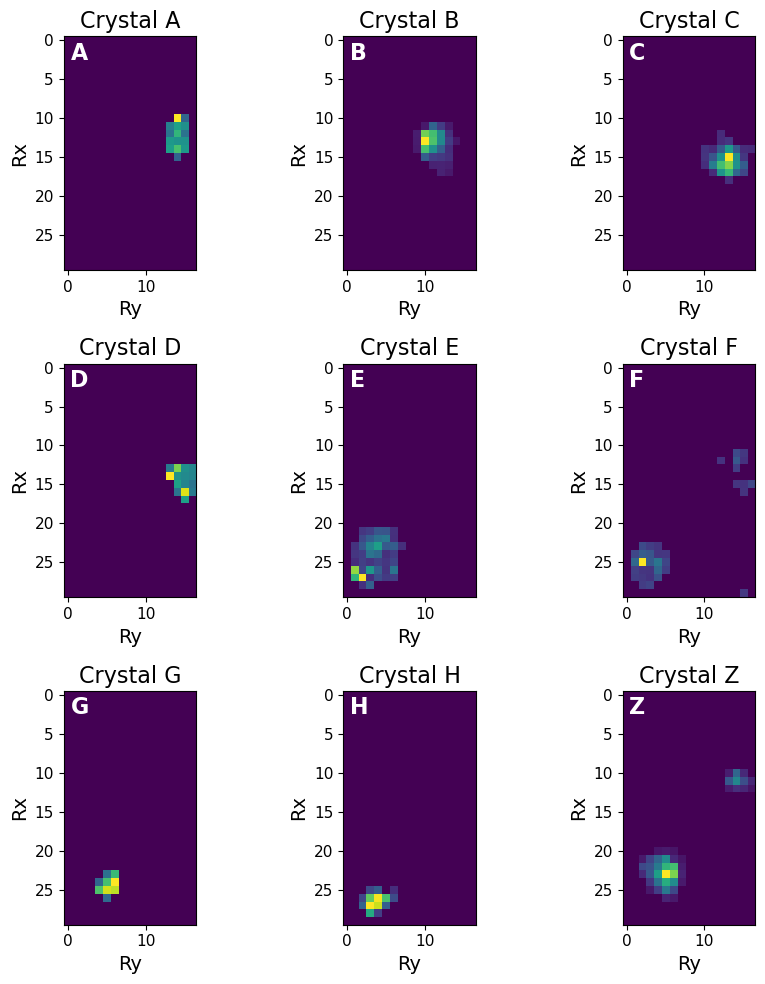

In [52]:
fig, axes = plt.subplots(3, 3, figsize=[10, 10])
axes = axes.flatten()

for i, j in enumerate(np.unique(lvl2)):
    
    CL = FullDataset[:, 8] == j
    Vectors = FullDataset[CL]
    CrystalData = Vectors[:,0:8].astype('float')

    Rxc = CrystalData[:,3].astype('float')
    Ryc = CrystalData[:,4].astype('float')
    
    Rxmax, Rymax = C1, C2
    
    image = np.zeros((Rxmax, Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')] = CrystalData[:,2]
    
    axes[i].imshow(image)
    axes[i].set_title('Crystal {0}'.format(j))
    axes[i].text(0.05, 0.9, j, transform=axes[i].transAxes, fontsize=16, color='white', weight='bold')
    axes[i].set_xlabel('Ry')
    axes[i].set_ylabel('Rx')

    fig.tight_layout()